# Запуск обучения всех моделей и сравнение логов

1. Запускает по очереди обучение REINFORCE, REINFORCE+baseline и TRPO (те же параметры, что в `scripts/train_*.sh`).
2. Строит на одном наборе графиков все метрики из папки `logs/` по каждому из трёх логов.

**Внимание:** при повторном запуске ячеек обучения файлы в `logs/` будут перезаписаны. Чтобы сохранить старые результаты, скопируйте их до повторного обучения.

In [1]:
import json
import subprocess
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: /Users/vasilij/Documents/RL_proj2


In [2]:
# 1. Обучение REINFORCE (перезаписывает logs/training_history_reinforce.json)
# Параметры из config/settings.py
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--agent_method", "reinforce",
     "--reward_step", "-2.0", "--reward_goal", "4.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.0001",
     "--entropy_coef", "0.8", "--max_grad_norm", "100.0",
     "--save_model", "model_reinforce.pth",
     "--history_path", "logs/training_history_reinforce.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("REINFORCE done.")

2026-03-04 15:36:13 [INFO] === Starting Training Session ===
2026-03-04 15:36:13 [INFO] Method: reinforce | Disks: 4
2026-03-04 15:36:18 [INFO] episode=50 | reward=-366.20 | steps=183 | success=False | success_rate=18.0% | loss=-176.9233 | entropy=1.6017 | entropy_coef=0.8000
2026-03-04 15:36:21 [INFO] episode=100 | reward=-325.96 | steps=163 | success=False | success_rate=28.0% | loss=-176.4031 | entropy=1.5783 | entropy_coef=0.8000
2026-03-04 15:36:25 [INFO] episode=150 | reward=-355.48 | steps=178 | success=False | success_rate=22.0% | loss=-173.8975 | entropy=1.6029 | entropy_coef=0.8000
2026-03-04 15:36:28 [INFO] episode=200 | reward=-368.64 | steps=184 | success=False | success_rate=12.0% | loss=-182.4087 | entropy=1.5993 | entropy_coef=0.8000
2026-03-04 15:36:31 [INFO] episode=250 | reward=-347.72 | steps=174 | success=False | success_rate=24.0% | loss=-175.8362 | entropy=1.5833 | entropy_coef=0.8000
2026-03-04 15:36:35 [INFO] episode=300 | reward=-360.00 | steps=180 | success=F

Successfully saved training history to logs/training_history_reinforce.json
REINFORCE done.


In [3]:
# 2. Обучение REINFORCE+baseline (перезаписывает logs/training_history_reinforce_baseline.json)
# Параметры из config/settings.py
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--agent_method", "reinforce_baseline",
     "--reward_step", "-2.0", "--reward_goal", "4.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.01",
     "--entropy_coef", "0.8", "--max_grad_norm", "5.0",
     "--save_model", "model_reinforce_baseline.pth",
     "--history_path", "logs/training_history_reinforce_baseline.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("REINFORCE+baseline done.")

2026-03-04 15:47:14 [INFO] === Starting Training Session ===
2026-03-04 15:47:14 [INFO] Method: reinforce_baseline | Disks: 4
2026-03-04 15:47:17 [INFO] episode=50 | reward=-330.52 | steps=165 | success=False | success_rate=26.0% | loss=3.6200 | entropy=1.5107 | entropy_coef=0.8000
2026-03-04 15:47:21 [INFO] episode=100 | reward=-364.08 | steps=182 | success=False | success_rate=14.0% | loss=-1.0339 | entropy=1.5436 | entropy_coef=0.8000
2026-03-04 15:47:24 [INFO] episode=150 | reward=-354.04 | steps=177 | success=False | success_rate=20.0% | loss=3.5923 | entropy=1.6101 | entropy_coef=0.8000
2026-03-04 15:47:28 [INFO] episode=200 | reward=-336.88 | steps=169 | success=False | success_rate=32.0% | loss=-0.1851 | entropy=1.5874 | entropy_coef=0.8000
2026-03-04 15:47:31 [INFO] episode=250 | reward=-348.32 | steps=174 | success=False | success_rate=26.0% | loss=-4.9714 | entropy=1.5794 | entropy_coef=0.8000
2026-03-04 15:47:34 [INFO] episode=300 | reward=-326.64 | steps=163 | success=Fals

Successfully saved training history to logs/training_history_reinforce_baseline.json
REINFORCE+baseline done.


In [4]:
# 3. Обучение TRPO (перезаписывает logs/training_history_trpo.json)
# Параметры из config/settings.py + learning rate и TRPO
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--agent_method", "trpo",
     "--reward_step", "-2.0", "--reward_goal", "4.0",
     "--reward_invalid_move", "0", "--reward_correct_placement", "2",
     "--no-use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--learning_rate", "0.001",
     "--entropy_coef", "0.2", "--episodes_per_update", "10",
     "--trpo_max_kl", "0.05", "--trpo_cg_iters", "20",
     "--trpo_backtrack_iters", "15", "--trpo_backtrack_coef", "0.5",
     "--trpo_max_abs_advantage", "0.0", "--trpo_max_grad_norm_cg", "50.0",
     "--trpo_entropy_coef", "0.1", "--trpo_damping", "0.1",
     "--save_model", "model_trpo.pth",
     "--history_path", "logs/training_history_trpo.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("TRPO done.")

2026-03-04 15:51:02 [INFO] === Starting Training Session ===
2026-03-04 15:51:02 [INFO] Method: trpo | Disks: 4
2026-03-04 15:51:04 [INFO] episode=50 | reward=-348.96 | steps=174 | success=False | success_rate=20.0% | loss=-0.0507 | entropy=1.5216 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 15:51:07 [INFO] episode=100 | reward=-341.88 | steps=171 | success=False | success_rate=22.0% | loss=-0.0214 | entropy=1.5748 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 15:51:09 [INFO] episode=150 | reward=-319.64 | steps=160 | success=False | success_rate=26.0% | loss=-0.0267 | entropy=1.5534 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 15:51:10 [INFO] episode=200 | reward=-303.68 | steps=152 | success=False | success_rate=36.0% | loss=-0.0359 | entropy=1.5818 | entropy_coef=0.1000 | accepted=1.0000
2026-03-04 15:51:12 [INFO] episode=250 | reward=-333.76 | steps=167 | success=False | success_rate=28.0% | loss=-0.0267 | entropy=1.5736 | entropy_coef=0.1000 | accepted=1.0000
2026

Successfully saved training history to logs/training_history_trpo.json
TRPO done.


## Графики как в plot.py: Reward, Success Rate, Steps (все модели на одной figure)

Три подграфика в столбец: (1) Total Reward per Episode, (2) Success Rate (Rolling Window 100), (3) Steps per Episode. На каждом — кривые для REINFORCE, REINFORCE+baseline и TRPO.

In [5]:
LOG_FILES = {
    "REINFORCE": PROJECT_ROOT / "logs" / "training_history_reinforce.json",
    "REINFORCE+baseline": PROJECT_ROOT / "logs" / "training_history_reinforce_baseline.json",
    "TRPO": PROJECT_ROOT / "logs" / "training_history_trpo.json",
}

def load_history(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

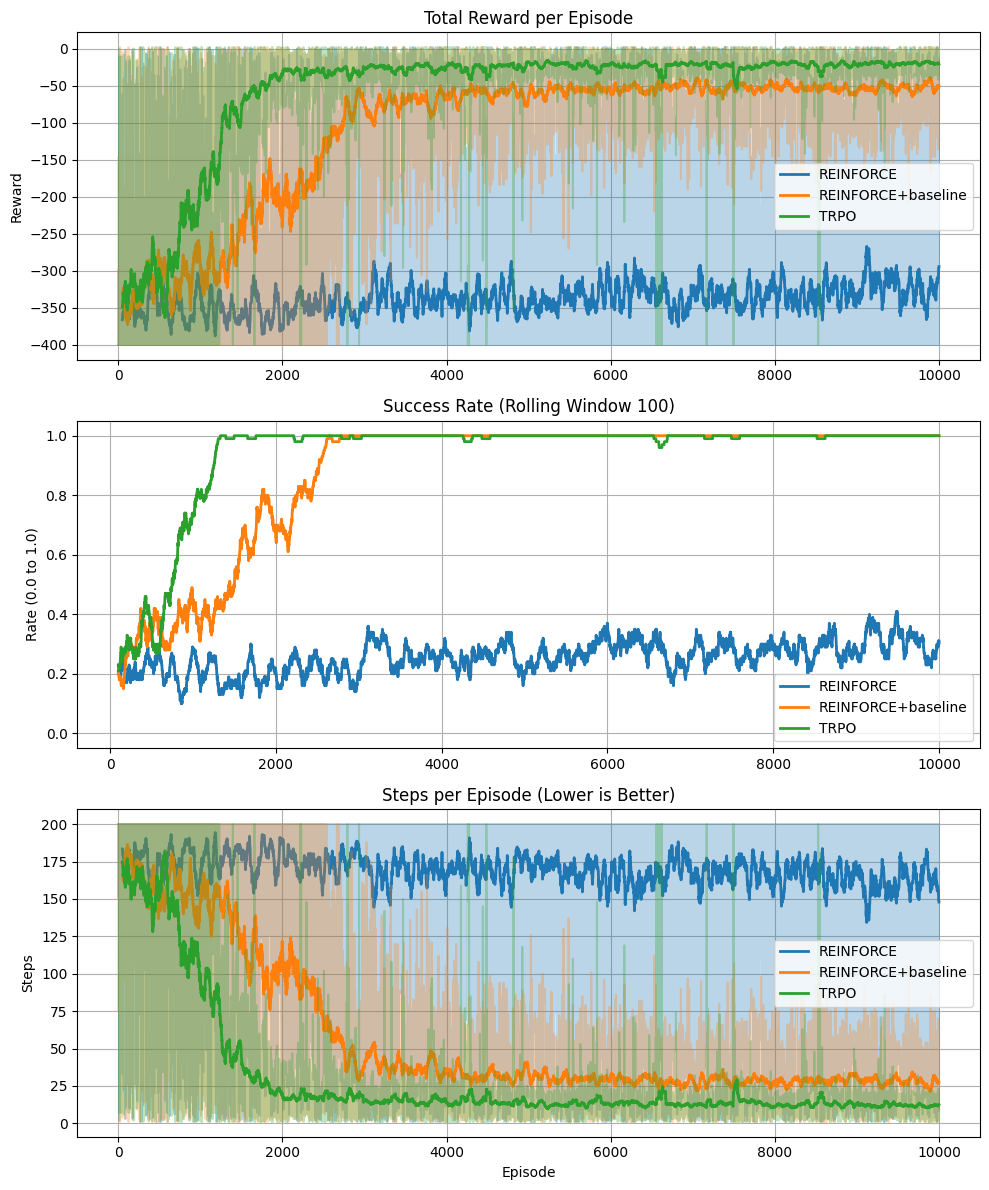

График сохранён: /Users/vasilij/Documents/RL_proj2/experiments/training_curves.png


In [6]:
def moving_average(data, window=50):
    """Сглаживание графика для лучшей читаемости (как в plot.py)."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="valid")

colors = {"REINFORCE": "C0", "REINFORCE+baseline": "C1", "TRPO": "C2"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_path = PROJECT_ROOT / "experiments" / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)